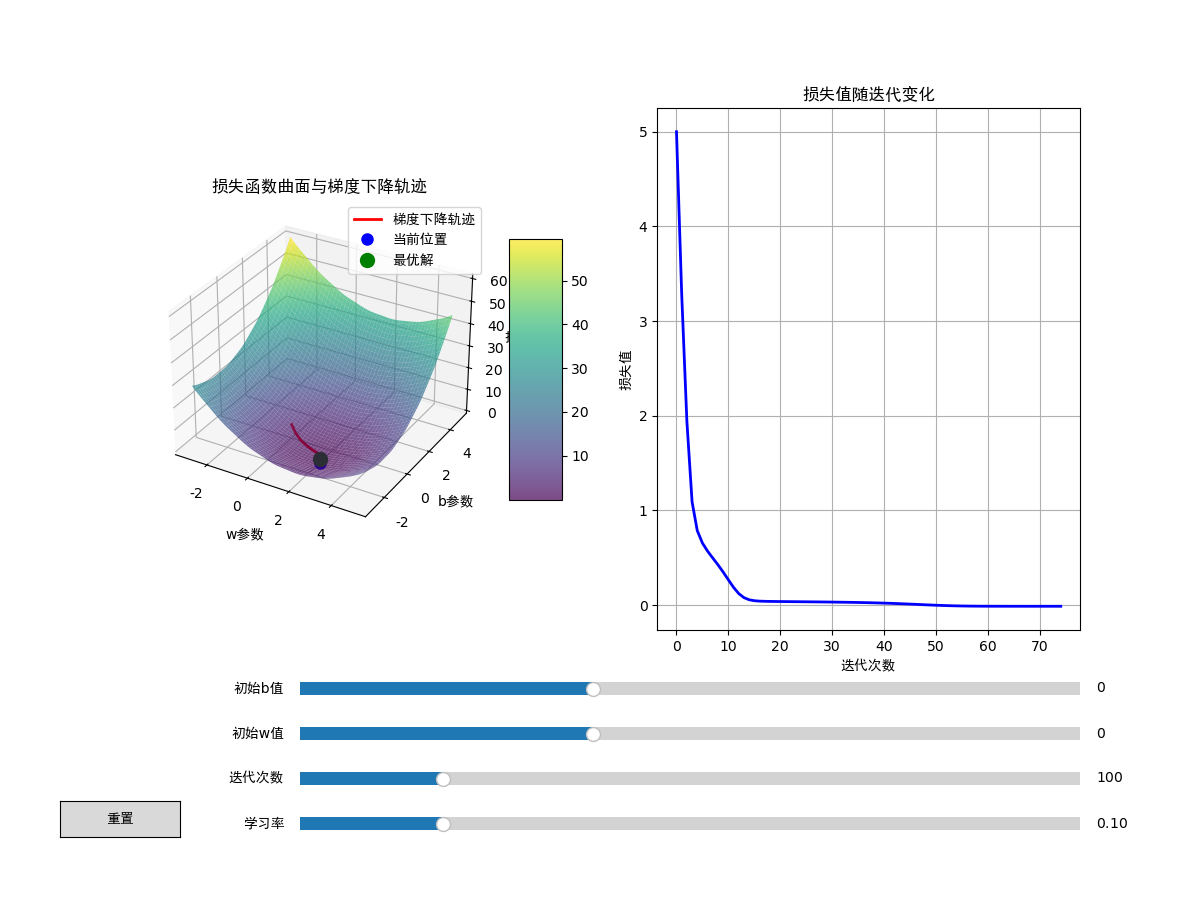

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# Notebook交互模式设置
%matplotlib widget

# 设置中文字体
plt.rcParams["font.family"] = ["sans-serif", "SimHei"]
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 定义损失函数
def loss_function(w, b):
    return (w - 2)**2 + (b + 1)** 2 + 0.1 * np.sin(5*w) + 0.1 * np.sin(5*b)

# 计算梯度
def compute_gradient(w, b):
    dw = 2 * (w - 2) + 0.5 * np.cos(5*w)
    db = 2 * (b + 1) + 0.5 * np.cos(5*b)
    return dw, db

# 梯度下降迭代
def gradient_descent(w_init, b_init, learning_rate, num_iterations):
    w_history = [w_init]
    b_history = [b_init]
    loss_history = [loss_function(w_init, b_init)]
    
    w_current, b_current = w_init, b_init
    
    for i in range(num_iterations):
        dw, db = compute_gradient(w_current, b_current)
        w_current -= learning_rate * dw
        b_current -= learning_rate * db
        
        w_history.append(w_current)
        b_history.append(b_current)
        loss_history.append(loss_function(w_current, b_current))
        
        if i > 0 and abs(loss_history[-1] - loss_history[-2]) < 1e-6:
            break
            
    return w_history, b_history, loss_history

# 创建图形 - 增加底部边距，为滑块留出空间
fig = plt.figure(figsize=(12, 9))  # 增加高度，避免拥挤
plt.subplots_adjust(bottom=0.3)  # 底部留出30%空间给控件

# 创建子图 - 调整子图位置，避免与滑块重叠
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122)

# 重新设置滑块位置（更靠下，增加间距）
ax_init_b = plt.axes([0.25, 0.22, 0.65, 0.03])    # 最上方滑块
ax_init_w = plt.axes([0.25, 0.17, 0.65, 0.03])
ax_iterations = plt.axes([0.25, 0.12, 0.65, 0.03])
ax_learning_rate = plt.axes([0.25, 0.07, 0.65, 0.03])  # 最下方滑块

# 创建滑块
slider_lr = Slider(ax_learning_rate, '学习率', 0.01, 0.5, valinit=0.1)
slider_iter = Slider(ax_iterations, '迭代次数', 10, 500, valinit=100, valstep=10)
slider_init_w = Slider(ax_init_w, '初始w值', -3, 5, valinit=0)
slider_init_b = Slider(ax_init_b, '初始b值', -3, 5, valinit=0)

# 创建重置按钮（调整位置）
reset_ax = plt.axes([0.05, 0.07, 0.1, 0.04])
button = Button(reset_ax, '重置', hovercolor='0.975')

# 生成网格数据
w_grid = np.linspace(-3, 5, 100)
b_grid = np.linspace(-3, 5, 100)
W, B = np.meshgrid(w_grid, b_grid)
L = loss_function(W, B)

# 绘制3D曲面
surf = ax1.plot_surface(W, B, L, cmap='viridis', alpha=0.7, edgecolor='none')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# 初始化轨迹线和点
trajectory_line, = ax1.plot([], [], [], 'r-', linewidth=2, label='梯度下降轨迹')
current_point, = ax1.plot([], [], [], 'bo', markersize=8, label='当前位置')
optimal_point, = ax1.plot([2], [-1], [loss_function(2, -1)], 'go', markersize=10, label='最优解')

# 设置3D图属性
ax1.set_xlabel('w参数')
ax1.set_ylabel('b参数')
ax1.set_zlabel('损失值')
ax1.set_title('损失函数曲面与梯度下降轨迹')
ax1.legend()

# 初始化损失曲线
loss_line, = ax2.plot([], [], 'b-', linewidth=2)
ax2.set_xlabel('迭代次数')
ax2.set_ylabel('损失值')
ax2.set_title('损失值随迭代变化')
ax2.grid(True)

# 更新函数
def update(val):
    """
    滑块参数变化时触发的更新函数，用于重新执行梯度下降并刷新可视化结果
    参数 val: 滑块的当前值（由滑块控件自动传入，此处未直接使用但需保留参数位）
    """
    # 1. 从滑块获取当前用户设置的参数值
    learning_rate = slider_lr.val  # 获取"学习率"滑块的当前值（步长大小）
    num_iterations = int(slider_iter.val)  # 获取"迭代次数"滑块的当前值（转为整数）
    init_w = slider_init_w.val  # 获取"初始w值"滑块的当前值（参数w的起点）
    init_b = slider_init_b.val  # 获取"初始b值"滑块的当前值（参数b的起点）
    
    # 2. 用当前参数执行梯度下降算法，获取迭代过程的历史记录
    # 返回值：
    # w_history: 每次迭代后w的取值列表
    # b_history: 每次迭代后b的取值列表
    # loss_history: 每次迭代后对应的损失值列表
    w_history, b_history, loss_history = gradient_descent(
        init_w, init_b, learning_rate, num_iterations
    )
    
    # 3. 更新3D图中的梯度下降轨迹线
    # set_data_3d方法用于更新3D线条的数据，参数分别为x(w)、y(b)、z(损失值)坐标列表
    trajectory_line.set_data_3d(w_history, b_history, loss_history)
    
    # 4. 更新3D图中的当前点（显示最后一次迭代的位置）
    # 取历史记录的最后一个元素作为当前点坐标，用列表包装确保维度匹配
    current_point.set_data_3d([w_history[-1]], [b_history[-1]], [loss_history[-1]])
    
    # 5. 更新右侧损失值变化曲线
    # x轴为迭代次数（0到len(loss_history)-1），y轴为对应的损失值
    loss_line.set_data(range(len(loss_history)), loss_history)
    ax2.relim()  # 重新计算坐标轴范围（根据新数据调整）
    ax2.autoscale_view()  # 自动调整坐标轴视图，确保所有数据可见
    
    # 6. 触发画布重绘，使所有更新生效（异步执行，避免界面卡顿）
    fig.canvas.draw_idle()

# 重置函数
def reset(event):
    slider_lr.reset()
    slider_iter.reset()
    slider_init_w.reset()
    slider_init_b.reset()
    update(None)

# 绑定事件
slider_lr.on_changed(update)
slider_iter.on_changed(update)
slider_init_w.on_changed(update)
slider_init_b.on_changed(update)
button.on_clicked(reset)

# 初始更新
update(None)

plt.show()